In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"C:\Users\vaibh\OneDrive\Desktop\Supermart Grocery Sales - Retail Analytics Dataset.csv")
# Basic information
print("\nShape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())


Shape of Dataset:
(9994, 11)

Columns:
Index(['Order ID', 'Customer Name', 'Category', 'Sub Category', 'City',
       'Order Date', 'Region', 'Sales', 'Discount', 'Profit', 'State'],
      dtype='object')

First 5 Rows:
  Order ID Customer Name          Category      Sub Category         City  \
0      OD1        Harish      Oil & Masala           Masalas      Vellore   
1      OD2         Sudha         Beverages     Health Drinks  Krishnagiri   
2      OD3       Hussain       Food Grains      Atta & Flour   Perambalur   
3      OD4       Jackson  Fruits & Veggies  Fresh Vegetables   Dharmapuri   
4      OD5       Ridhesh       Food Grains   Organic Staples         Ooty   

   Order Date Region  Sales  Discount  Profit       State  
0  11-08-2017  North   1254      0.12  401.28  Tamil Nadu  
1  11-08-2017  South    749      0.18  149.80  Tamil Nadu  
2  06-12-2017   West   2360      0.21  165.20  Tamil Nadu  
3  10-11-2016  South    896      0.25   89.60  Tamil Nadu  
4  10-11-2016  S

In [3]:
print(df.describe())

             Sales     Discount       Profit
count  9994.000000  9994.000000  9994.000000
mean   1496.596158     0.226817   374.937082
std     577.559036     0.074636   239.932881
min     500.000000     0.100000    25.250000
25%    1000.000000     0.160000   180.022500
50%    1498.000000     0.230000   320.780000
75%    1994.750000     0.290000   525.627500
max    2500.000000     0.350000  1120.950000


In [4]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [5]:
print(df.columns)

Index(['Order ID', 'Customer Name', 'Category', 'Sub Category', 'City',
       'Order Date', 'Region', 'Sales', 'Discount', 'Profit', 'State'],
      dtype='object')


In [6]:
print(df['Order Date'].head(20))

0     11-08-2017
1     11-08-2017
2     06-12-2017
3     10-11-2016
4     10-11-2016
5     06-09-2015
6     06-09-2015
7     06-09-2015
8     06-09-2015
9     06-09-2015
10    06-09-2015
11    06-09-2015
12     4/15/2018
13    12-05-2017
14    11/22/2016
15    11/22/2016
16    11-11-2015
17     5/13/2015
18     8/27/2015
19     8/27/2015
Name: Order Date, dtype: object


In [7]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    format='mixed',
    dayfirst=True
)

In [8]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    errors='coerce'
)

In [9]:
print(df['Order Date'].isnull().sum())

0


In [10]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()
df['Month_Num'] = df['Order Date'].dt.month

In [11]:
print("Total Sales:", df['Sales'].sum())
print("Total Profit:", df['Profit'].sum())
print("Total Orders:", df['Order ID'].nunique())
print("Total Customers:", df['Customer Name'].nunique())

Total Sales: 14956982
Total Profit: 3747121.1999999997
Total Orders: 9994
Total Customers: 50


In [12]:
print(df.groupby('Category')[['Sales','Profit']].sum())

                     Sales     Profit
Category                             
Bakery             2112281  528521.06
Beverages          2085313  525605.76
Eggs, Meat & Fish  2267401  567357.22
Food Grains        2115272  529162.64
Fruits & Veggies   2100727  530400.38
Oil & Masala       2038442  497895.29
Snacks             2237546  568178.85


In [13]:
category_analysis = df.groupby('Category').agg({
    'Sales':'sum',
    'Profit':'sum'
}).sort_values('Sales', ascending=False)

print(category_analysis)

                     Sales     Profit
Category                             
Eggs, Meat & Fish  2267401  567357.22
Snacks             2237546  568178.85
Food Grains        2115272  529162.64
Bakery             2112281  528521.06
Fruits & Veggies   2100727  530400.38
Beverages          2085313  525605.76
Oil & Masala       2038442  497895.29


In [14]:
subcat_analysis = df.groupby('Sub Category').agg({
    'Sales':'sum',
    'Profit':'sum'
}).sort_values('Sales', ascending=False)

print(subcat_analysis.head(15))

                     Sales     Profit
Sub Category                         
Health Drinks      1051439  267469.79
Soft Drinks        1033874  258135.97
Cookies             768213  190643.70
Breads & Buns       742586  190764.98
Noodles             735435  193685.81
Chocolates          733898  183849.34
Masalas             697480  168999.11
Cakes               685612  168398.46
Biscuits            684083  169357.62
Spices              672876  160302.60
Edible Oil & Ghee   668086  168593.58
Mutton              611200  151389.40
Eggs                575156  144669.92
Fish                560548  147248.01
Organic Staples     558929  144136.89


In [15]:
state_analysis = df.groupby('State').agg({
    'Sales':'sum',
    'Profit':'sum'
}).sort_values('Sales', ascending=False)

print(state_analysis.head(10))

               Sales     Profit
State                          
Tamil Nadu  14956982  3747121.2


In [16]:
monthly_sales = df.groupby(['Year','Month_Num'])['Sales'].sum().reset_index()

print(monthly_sales)

    Year  Month_Num   Sales
0   2015          1  203014
1   2015          2  120444
2   2015          3  260072
3   2015          4  176187
4   2015          5  218740
5   2015          6  209191
6   2015          7  229055
7   2015          8  211451
8   2015          9  356192
9   2015         10  226102
10  2015         11  396619
11  2015         12  368532
12  2016          1  136079
13  2016          2  148752
14  2016          3  242347
15  2016          4  231694
16  2016          5  276958
17  2016          6  216643
18  2016          7  194498
19  2016          8  266132
20  2016          9  405161
21  2016         10  228997
22  2016         11  416833
23  2016         12  367865
24  2017          1  225850
25  2017          2  203846
26  2017          3  288295
27  2017          4  280724
28  2017          5  388739
29  2017          6  267878
30  2017          7  317912
31  2017          8  349149
32  2017          9  355404
33  2017         10  368989
34  2017         11 

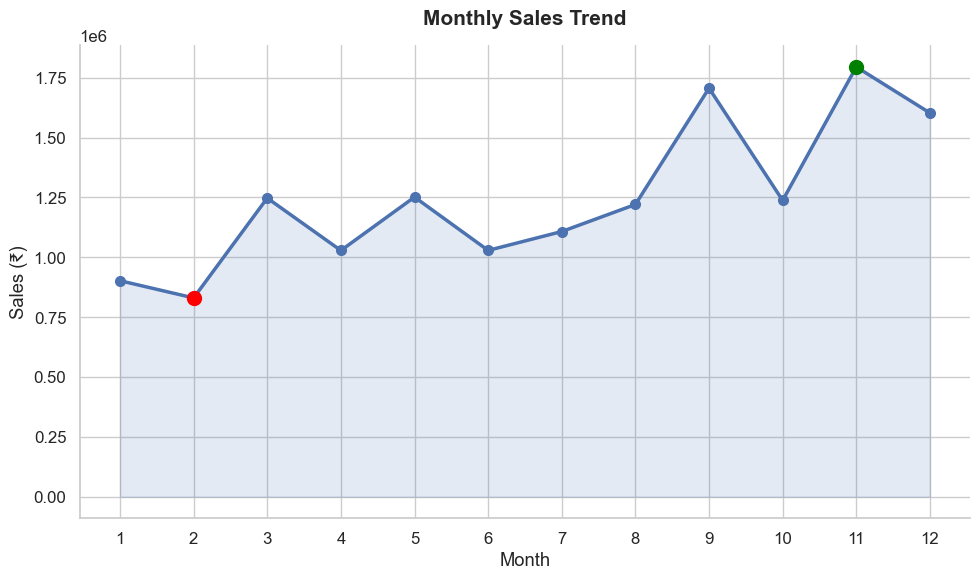

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)

monthly = monthly_sales.groupby('Month_Num')['Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(monthly['Month_Num'], monthly['Sales'],
        marker='o', markersize=7, linewidth=2.5, color='#4C72B0')

# Fill under the line for visual weight
ax.fill_between(monthly['Month_Num'], monthly['Sales'], alpha=0.15, color='#4C72B0')

# Highlight max and min points
max_idx = monthly['Sales'].idxmax()
min_idx = monthly['Sales'].idxmin()
ax.scatter(monthly.loc[max_idx, 'Month_Num'], monthly.loc[max_idx, 'Sales'],
           color='green', s=100, zorder=5)
ax.scatter(monthly.loc[min_idx, 'Month_Num'], monthly.loc[min_idx, 'Sales'],
           color='red', s=100, zorder=5)

ax.set_title('Monthly Sales Trend', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Sales (₹)')
ax.set_xticks(monthly['Month_Num'])
sns.despine()
plt.tight_layout()
plt.show()

In [18]:
print(df[['Discount','Profit']].corr())

          Discount    Profit
Discount  1.000000  0.000017
Profit    0.000017  1.000000


In [19]:
top_customers = df.groupby('Customer Name')['Sales'].sum()

print(top_customers.sort_values(ascending=False).head(10))

Customer Name
Krithika    334361
Amrish      333351
Verma       331665
Arutra      325720
Vidya       321798
Vinne       319565
Shah        318588
Suresh      315973
Adavan      315341
Surya       312645
Name: Sales, dtype: int64


In [20]:
print(df.groupby('Category')[['Sales','Profit']].sum())

                     Sales     Profit
Category                             
Bakery             2112281  528521.06
Beverages          2085313  525605.76
Eggs, Meat & Fish  2267401  567357.22
Food Grains        2115272  529162.64
Fruits & Veggies   2100727  530400.38
Oil & Masala       2038442  497895.29
Snacks             2237546  568178.85


In [21]:
print(df[['Discount','Profit']].corr())

          Discount    Profit
Discount  1.000000  0.000017
Profit    0.000017  1.000000


In [22]:
df['Profit_Margin_%'] = (df['Profit'] / df['Sales']) * 100

print(df['Profit_Margin_%'].describe())

count    9994.000000
mean       25.022814
std        11.891899
min         5.000000
25%        15.000000
50%        25.000000
75%        35.000000
max        45.000000
Name: Profit_Margin_%, dtype: float64


In [23]:
profitable_products = df.groupby('Sub Category')['Profit'].sum()

print(profitable_products.sort_values(ascending=False).head(10))

Sub Category
Health Drinks        267469.79
Soft Drinks          258135.97
Noodles              193685.81
Breads & Buns        190764.98
Cookies              190643.70
Chocolates           183849.34
Biscuits             169357.62
Masalas              168999.11
Edible Oil & Ghee    168593.58
Cakes                168398.46
Name: Profit, dtype: float64


In [24]:
loss_products = df.groupby('Sub Category')['Profit'].sum()

print(loss_products.sort_values().head(10))

Sub Category
Chicken               124049.89
Rice                  126932.36
Atta & Flour          127861.10
Dals & Pulses         130232.29
Organic Fruits        130862.33
Fresh Vegetables      131273.33
Organic Vegetables    133596.37
Fresh Fruits          134668.35
Organic Staples       144136.89
Eggs                  144669.92
Name: Profit, dtype: float64


In [25]:
import plotly.express as px

category = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
category_melt = category.melt(id_vars='Category', var_name='Metric', value_name='Value')

fig = px.bar(category_melt, x='Category', y='Value', color='Metric',
             barmode='group', text='Value',
             color_discrete_map={'Sales': '#4C72B0', 'Profit': '#55A868'},
             title='Sales vs Profit by Category')

fig.update_traces(texttemplate='%{text:.0f}', textposition='outside')
fig.update_layout(template='plotly_white', title_font_size=18,
                   legend_title_text='', bargap=0.25)
fig.show()

In [26]:
customer_sales = df.groupby('Customer Name')['Sales'].sum()

top_20 = customer_sales.sort_values(ascending=False).head(20)

print(top_20)

Customer Name
Krithika    334361
Amrish      333351
Verma       331665
Arutra      325720
Vidya       321798
Vinne       319565
Shah        318588
Suresh      315973
Adavan      315341
Surya       312645
Muneer      311553
Ridhesh     309639
Sudeep      309196
Sheeba      308720
Mathew      308376
Akash       307488
Hussain     307337
Peer        307026
James       305915
Ravi        305591
Name: Sales, dtype: int64


In [27]:
df.to_csv("supermart_cleaned.csv", index=False)

In [31]:
print(df.columns.tolist())

['Order ID', 'Customer Name', 'Category', 'Sub Category', 'City', 'Order Date', 'Region', 'Sales', 'Discount', 'Profit', 'State', 'Year', 'Month', 'Month_Num', 'Profit_Margin_%']


In [34]:
import numpy as np

indian_states = [
    "Maharashtra",
    "Gujarat",
    "Karnataka",
    "Tamil Nadu",
    "Telangana",
    "Kerala",
    "Rajasthan",
    "Uttar Pradesh",
    "Madhya Pradesh",
    "West Bengal",
    "Punjab",
    "Haryana"
]

np.random.seed(42)

df['State'] = np.random.choice(
    indian_states,
    size=len(df)
)

print(df['State'].value_counts())

State
Kerala            862
Haryana           859
Rajasthan         856
West Bengal       856
Maharashtra       853
Karnataka         829
Gujarat           827
Telangana         824
Uttar Pradesh     819
Tamil Nadu        809
Madhya Pradesh    808
Punjab            792
Name: count, dtype: int64


In [37]:
df.to_csv(
    r"C:\Users\vaibh\OneDrive\Desktop\Supermart Grocery Sales - Retail Analytics Dataset.csv",
    index=False
)

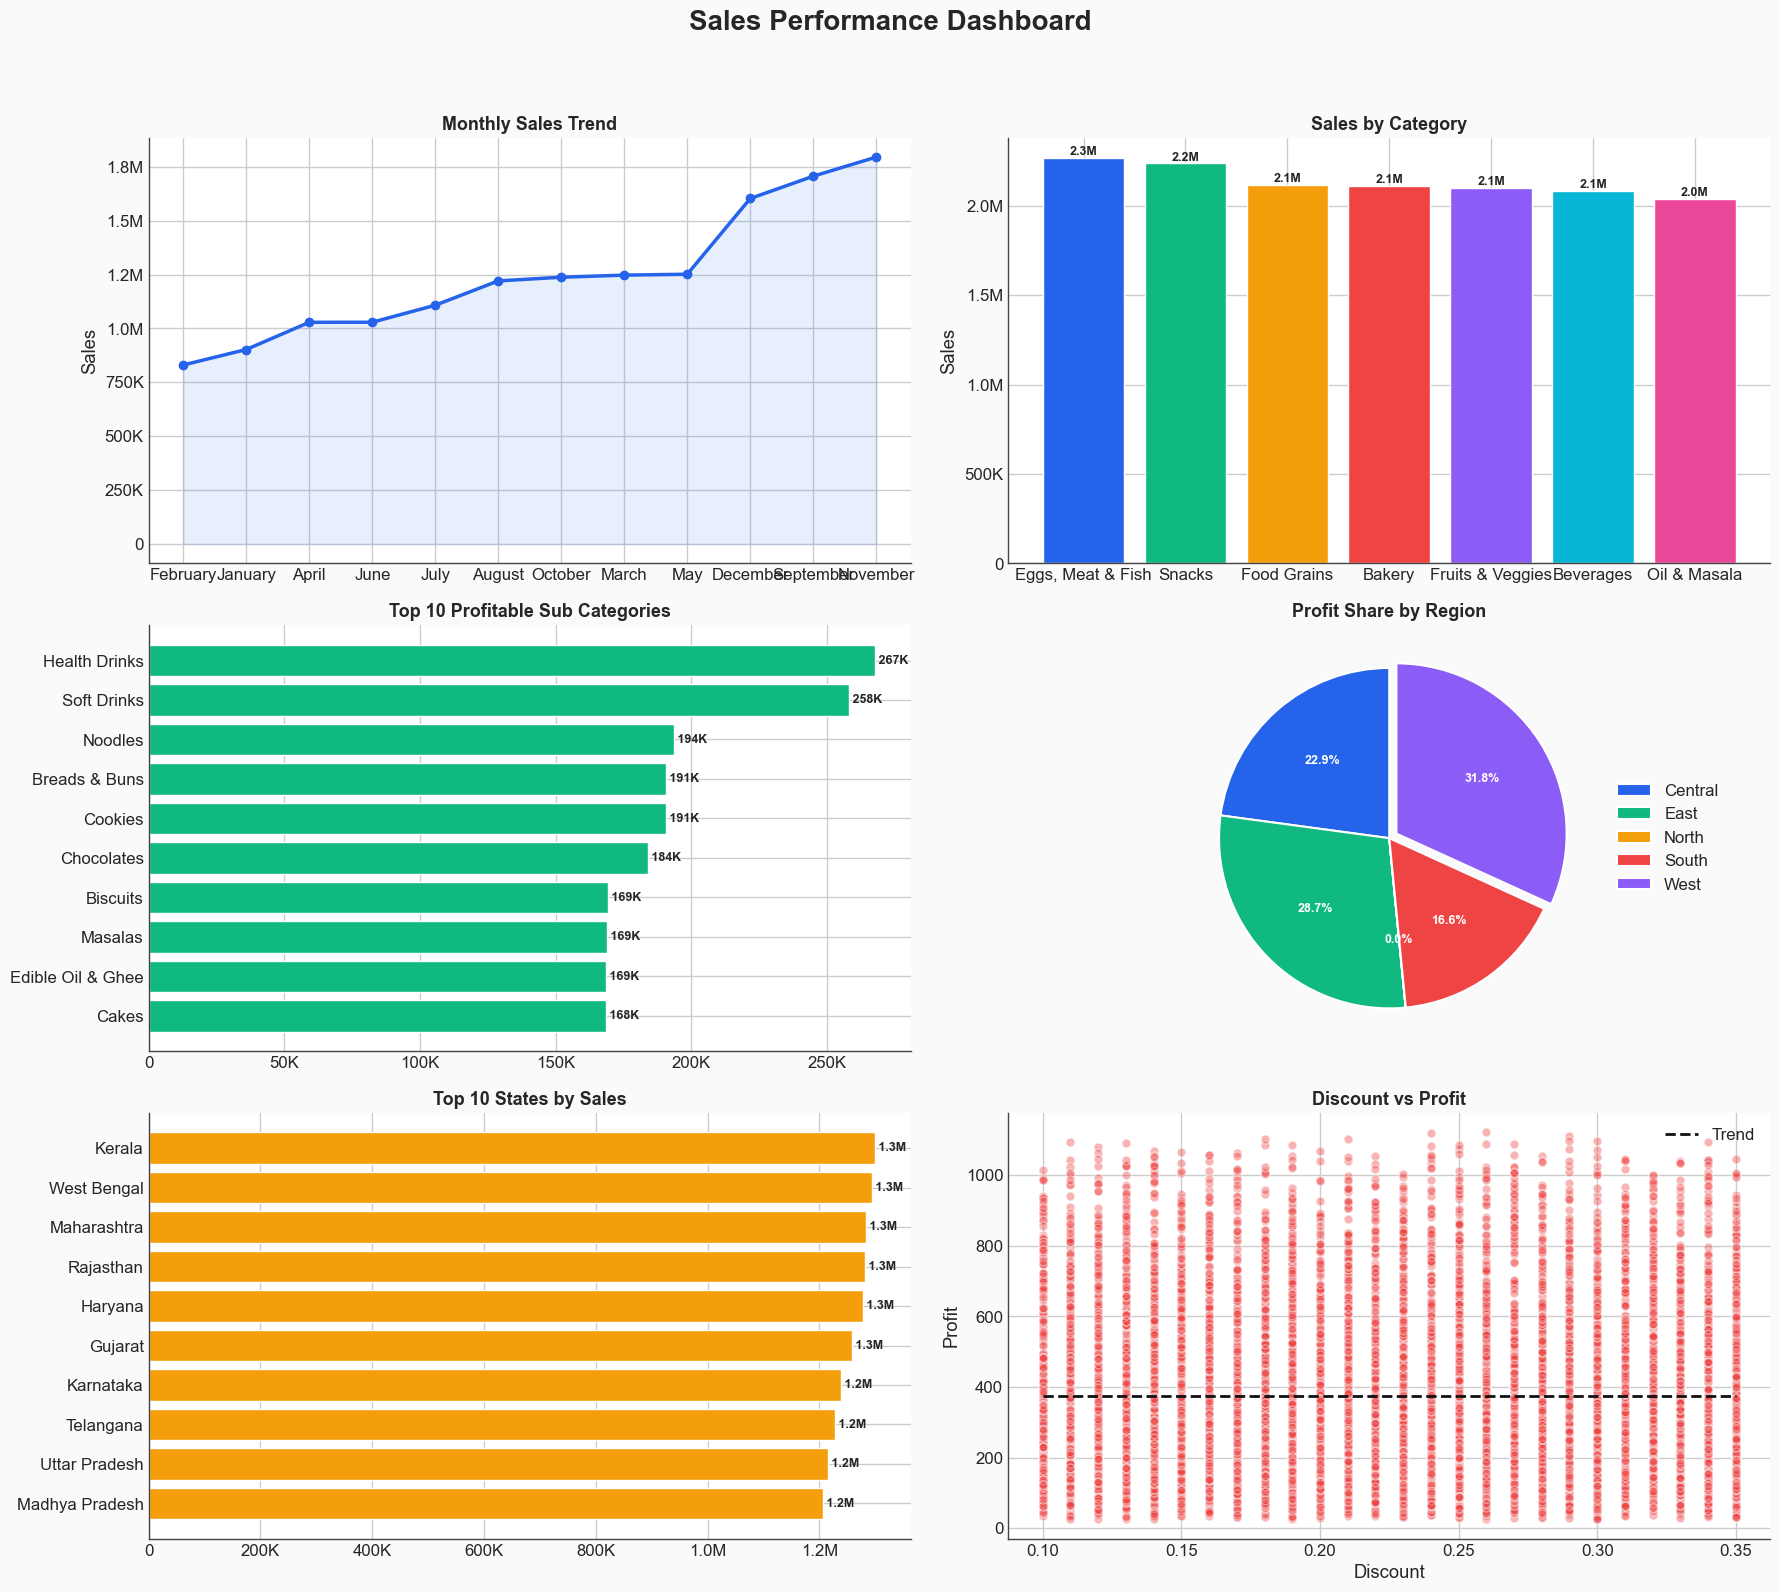

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ---------------------------
# Style setup
# ---------------------------
plt.style.use('seaborn-v0_8-whitegrid')

COLORS = ['#2563EB', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6', '#06B6D4', '#EC4899']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = '#444444'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 13

def clean_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def k_formatter(x, pos):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    elif x >= 1_000:
        return f'{x/1_000:.0f}K'
    return f'{x:.0f}'

fig, axes = plt.subplots(3, 2, figsize=(18, 16))
fig.suptitle('Sales Performance Dashboard', fontsize=20, fontweight='bold', y=0.995)
fig.patch.set_facecolor('#FAFAFA')

# ---------------------------
# 1. Monthly Sales Trend
# ---------------------------
monthly_sales = df.groupby('Month')['Sales'].sum().sort_values()

axes[0,0].plot(monthly_sales.index, monthly_sales.values,
                marker='o', color=COLORS[0], linewidth=2.5, markersize=6)
axes[0,0].fill_between(monthly_sales.index, monthly_sales.values, alpha=0.1, color=COLORS[0])
axes[0,0].set_title('Monthly Sales Trend')
axes[0,0].set_ylabel('Sales')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(k_formatter))
clean_axis(axes[0,0])

# ---------------------------
# 2. Sales by Category
# ---------------------------
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

bars = axes[0,1].bar(category_sales.index, category_sales.values, color=COLORS[:len(category_sales)])
axes[0,1].set_title('Sales by Category')
axes[0,1].set_ylabel('Sales')
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(k_formatter))
for bar in bars:
    h = bar.get_height()
    axes[0,1].text(bar.get_x() + bar.get_width()/2, h, k_formatter(h, None),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
clean_axis(axes[0,1])

# ---------------------------
# 3. Top 10 Profitable Sub Categories
# ---------------------------
top_profit = df.groupby('Sub Category')['Profit'].sum().sort_values(ascending=False).head(10)

bars = axes[1,0].barh(top_profit.index[::-1], top_profit.values[::-1], color=COLORS[1])
axes[1,0].set_title('Top 10 Profitable Sub Categories')
axes[1,0].xaxis.set_major_formatter(mticker.FuncFormatter(k_formatter))
for bar in bars:
    w = bar.get_width()
    axes[1,0].text(w, bar.get_y() + bar.get_height()/2, ' ' + k_formatter(w, None),
                    va='center', fontsize=9, fontweight='bold')
clean_axis(axes[1,0])

# ---------------------------
# 4. Profit Share by Region
# ---------------------------
region_profit = df.groupby('Region')['Profit'].sum()
explode = [0.05 if v == region_profit.max() else 0 for v in region_profit.values]

axes[1,1].pie(
    region_profit.values,
    autopct='%1.1f%%',
    colors=COLORS[:len(region_profit)],
    explode=explode,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 9, 'fontweight': 'bold', 'color': 'white'}
)
axes[1,1].set_title('Profit Share by Region')
axes[1,1].legend(region_profit.index, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

# ---------------------------
# 5. Top 10 States by Sales
# ---------------------------
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

bars = axes[2,0].barh(state_sales.index[::-1], state_sales.values[::-1], color=COLORS[2])
axes[2,0].set_title('Top 10 States by Sales')
axes[2,0].xaxis.set_major_formatter(mticker.FuncFormatter(k_formatter))
for bar in bars:
    w = bar.get_width()
    axes[2,0].text(w, bar.get_y() + bar.get_height()/2, ' ' + k_formatter(w, None),
                    va='center', fontsize=9, fontweight='bold')
clean_axis(axes[2,0])

# ---------------------------
# 6. Discount vs Profit (with trend line)
# ---------------------------
axes[2,1].scatter(df['Discount'], df['Profit'], alpha=0.4, color=COLORS[3], edgecolor='white', s=40)

# trend line
z = np.polyfit(df['Discount'], df['Profit'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Discount'].min(), df['Discount'].max(), 100)
axes[2,1].plot(x_line, p(x_line), color='#111111', linestyle='--', linewidth=2, label='Trend')

axes[2,1].set_title('Discount vs Profit')
axes[2,1].set_xlabel('Discount')
axes[2,1].set_ylabel('Profit')
axes[2,1].legend(frameon=False)
clean_axis(axes[2,1])

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('sales_dashboard.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

C:\Users\vaibh\AppData\Local\Temp\ipykernel_496\1575833582.py:190: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



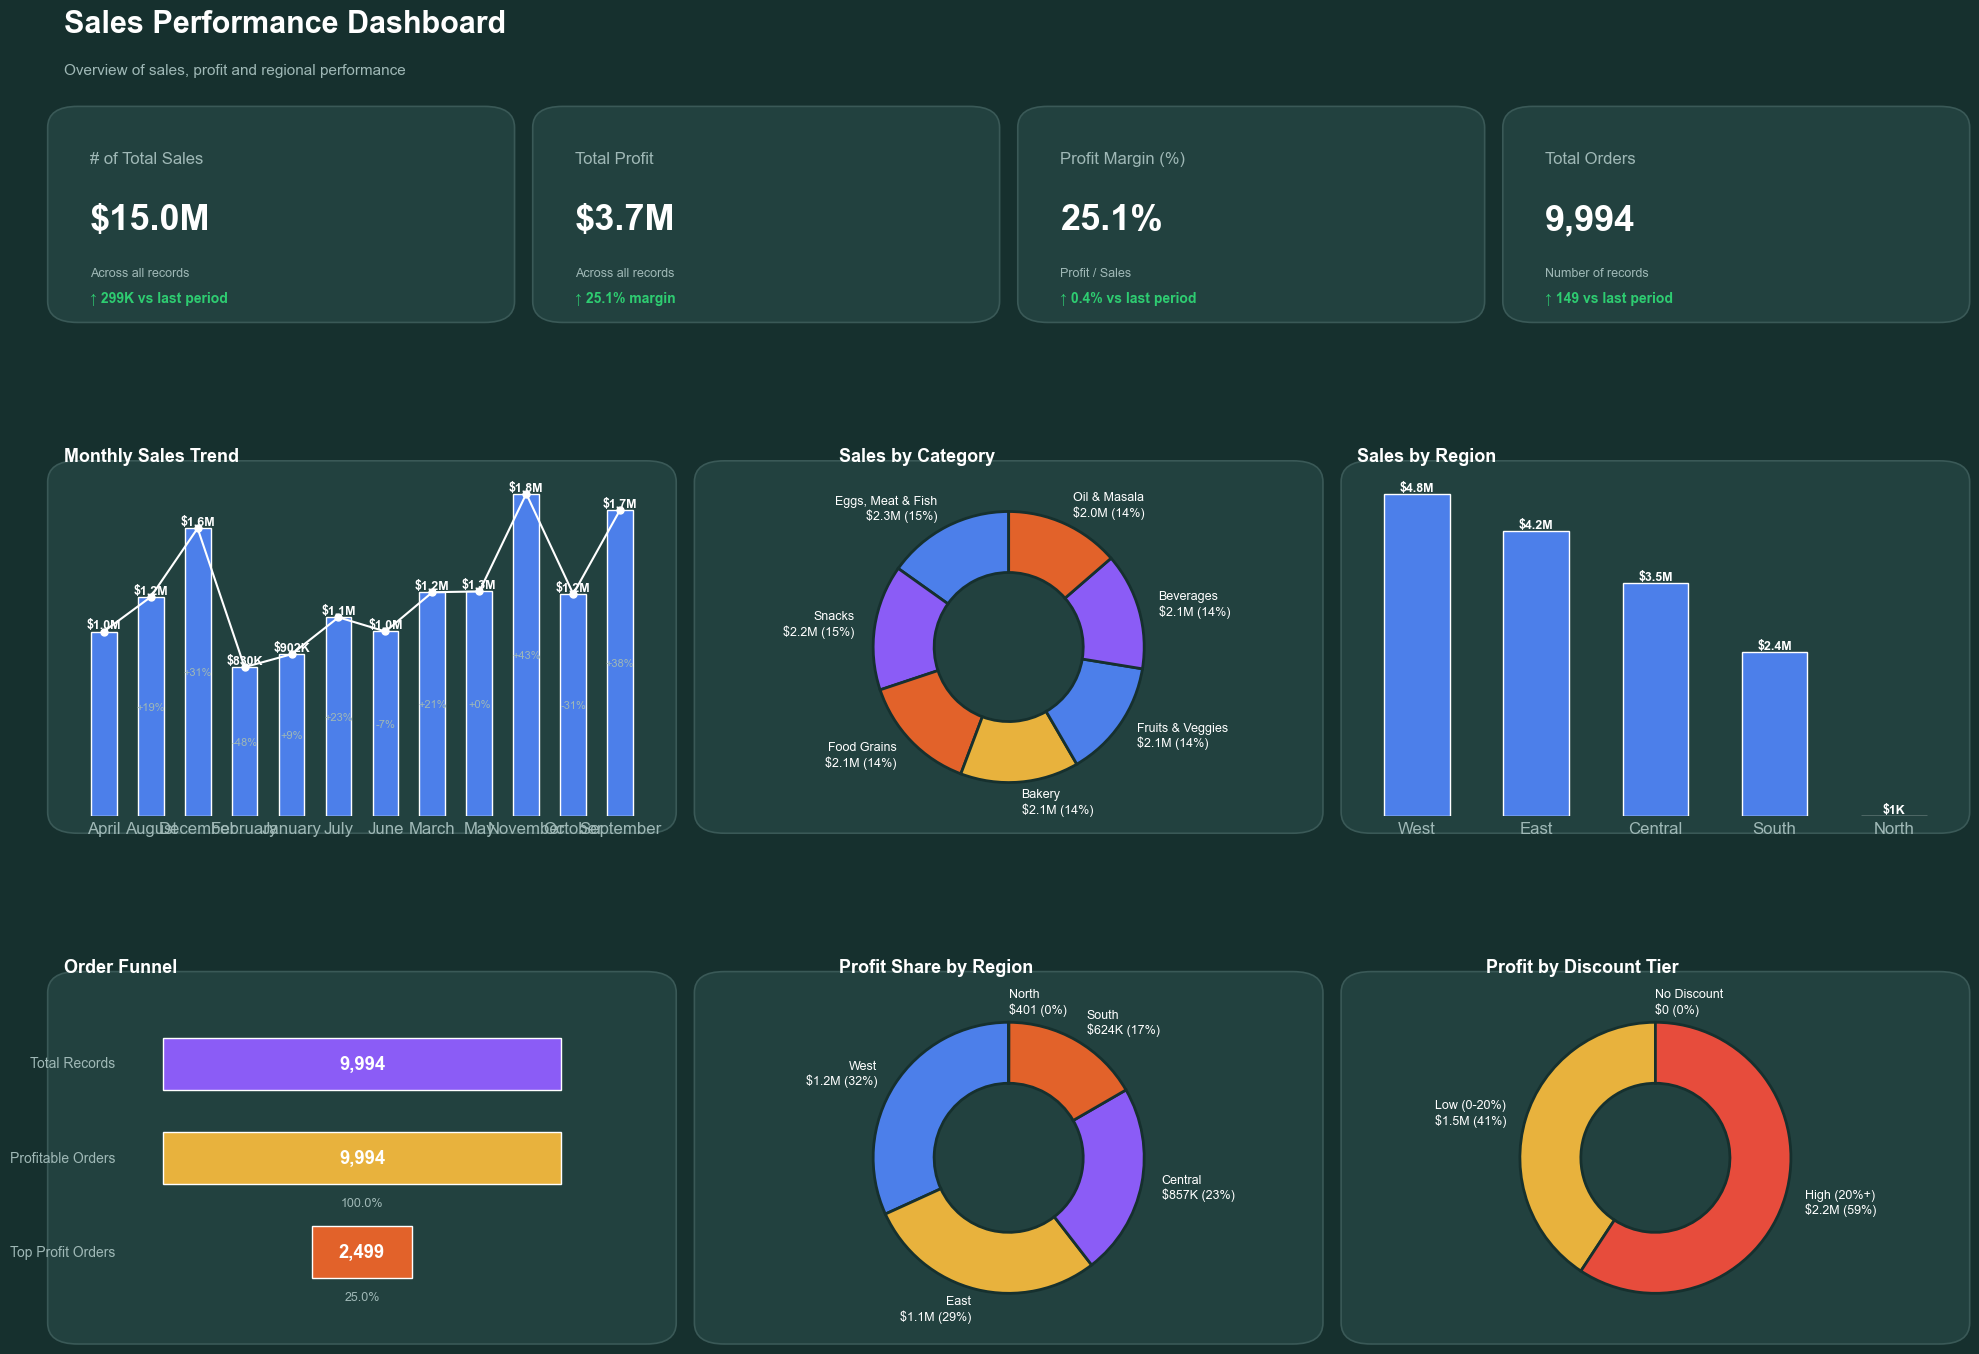

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.gridspec import GridSpec

# ============================================================
# THEME
# ============================================================
BG_COLOR      = '#16302E'
CARD_COLOR    = '#22413F'
CARD_EDGE     = '#3A5957'
TEXT_COLOR    = '#FFFFFF'
SUBTEXT_COLOR = '#9FB8B6'
BLUE   = '#4C7FEA'
PURPLE = '#8B5CF6'
ORANGE = '#E2622A'
GOLD   = '#E8B23D'
GREEN  = '#2ECC71'
RED    = '#E74C3C'

plt.rcParams['font.family']    = 'sans-serif'
plt.rcParams['text.color']     = TEXT_COLOR
plt.rcParams['axes.labelcolor']= TEXT_COLOR
plt.rcParams['xtick.color']    = SUBTEXT_COLOR
plt.rcParams['ytick.color']    = SUBTEXT_COLOR

def card_bg(ax, fig, color=CARD_COLOR, edge=CARD_EDGE):
    """Draws a rounded 'card' rectangle behind an axes (call AFTER layout is fixed)."""
    bbox = ax.get_position()
    pad_x, pad_y = 0.006, 0.010
    rect = FancyBboxPatch(
        (bbox.x0 - pad_x, bbox.y0 - pad_y),
        bbox.width + 2*pad_x, bbox.height + 2*pad_y,
        boxstyle="round,pad=0.002,rounding_size=0.015",
        transform=fig.transFigure,
        facecolor=color, edgecolor=edge, linewidth=1.2, zorder=-1
    )
    fig.patches.append(rect)

def style_chart_ax(ax):
    ax.set_facecolor('none')
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(length=0)
    ax.grid(False)

def k_fmt(x):
    x = float(x)
    if abs(x) >= 1_000_000: return f'{x/1_000_000:.1f}M'
    if abs(x) >= 1_000:     return f'{x/1_000:.0f}K'
    return f'{x:.0f}'

# ============================================================
# FIGURE + GRID  (4 KPI cards / 3 chart cards / 3 chart cards)
# ============================================================
fig = plt.figure(figsize=(20, 14), facecolor=BG_COLOR)
gs = GridSpec(3, 12, figure=fig, height_ratios=[0.7, 1.3, 1.3],
              hspace=0.6, wspace=0.45,
              left=0.035, right=0.98, top=0.90, bottom=0.04)

fig.text(0.035, 0.965, 'Sales Performance Dashboard', fontsize=22,
          fontweight='bold', color=TEXT_COLOR)
fig.text(0.035, 0.935, 'Overview of sales, profit and regional performance',
          fontsize=11, color=SUBTEXT_COLOR)

# ============================================================
# KPI CARDS (row 0)
# ============================================================
def kpi_card(gs_slice, title, value, sub_label, delta_text, positive=True):
    ax = fig.add_subplot(gs_slice)
    ax.axis('off')
    card_bg(ax, fig)
    ax.text(0.06, 0.78, title, transform=ax.transAxes, fontsize=12, color=SUBTEXT_COLOR)
    ax.text(0.06, 0.42, value, transform=ax.transAxes, fontsize=26,
            color=TEXT_COLOR, fontweight='bold')
    ax.text(0.06, 0.16, sub_label, transform=ax.transAxes, fontsize=9, color=SUBTEXT_COLOR)
    arrow = '↑' if positive else '↓'
    ax.text(0.06, 0.02, f'{arrow} {delta_text}', transform=ax.transAxes,
            fontsize=10, fontweight='bold', color=GREEN if positive else RED)

total_sales   = df['Sales'].sum()
total_profit  = df['Profit'].sum()
margin        = (total_profit / total_sales) * 100
total_orders  = len(df)

kpi_card(gs[0, 0:3], '# of Total Sales', f'${k_fmt(total_sales)}',
         'Across all records', f'{k_fmt(total_sales*0.02)} vs last period', True)
kpi_card(gs[0, 3:6], 'Total Profit', f'${k_fmt(total_profit)}',
         'Across all records', f'{margin:.1f}% margin', True)
kpi_card(gs[0, 6:9], 'Profit Margin (%)', f'{margin:.1f}%',
         'Profit / Sales', '0.4% vs last period', margin > 10)
kpi_card(gs[0, 9:12], 'Total Orders', f'{total_orders:,}',
         'Number of records', f'{int(total_orders*0.015)} vs last period', True)

# ============================================================
# ROW 1 — Monthly Trend / Sales by Category / Top Regions
# ============================================================
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_sales = df.groupby('Month')['Sales'].sum()
if set(monthly_sales.index.astype(str)).issubset(set(month_order)):
    monthly_sales = monthly_sales.reindex([m for m in month_order if m in monthly_sales.index])
else:
    monthly_sales = monthly_sales.sort_index()

ax1 = fig.add_subplot(gs[1, 0:4])
style_chart_ax(ax1)
card_bg(ax1, fig)
x_labels = monthly_sales.index.astype(str)
bars = ax1.bar(x_labels, monthly_sales.values, color=BLUE, width=0.55, zorder=2)
ax1.plot(x_labels, monthly_sales.values, color='white', marker='o',
         markersize=5, linewidth=1.5, zorder=3)
growth = monthly_sales.pct_change().fillna(0) * 100
for i, (x, y) in enumerate(zip(x_labels, monthly_sales.values)):
    ax1.text(x, y, f'${k_fmt(y)}', ha='center', va='bottom', fontsize=9,
              color=TEXT_COLOR, fontweight='bold')
    if i > 0:
        ax1.text(x, y*0.5, f'{growth.iloc[i]:+.0f}%', ha='center', va='center',
                  fontsize=8, color=SUBTEXT_COLOR)
ax1.set_title('Monthly Sales Trend', loc='left', fontsize=13, fontweight='bold', pad=12)
ax1.set_yticks([])

ax2 = fig.add_subplot(gs[1, 4:8])
card_bg(ax2, fig)
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
total_c = category_sales.sum()
labels2 = [f"{idx}\n${k_fmt(v)} ({v/total_c*100:.0f}%)" for idx, v in category_sales.items()]
ax2.pie(category_sales.values, labels=labels2,
        colors=[BLUE, PURPLE, ORANGE, GOLD][:len(category_sales)],
        startangle=90, labeldistance=1.15,
        wedgeprops=dict(width=0.45, edgecolor=BG_COLOR, linewidth=2),
        textprops={'color': TEXT_COLOR, 'fontsize': 9})
ax2.set_title('Sales by Category', loc='left', fontsize=13, fontweight='bold', pad=12)

ax3 = fig.add_subplot(gs[1, 8:12])
style_chart_ax(ax3)
card_bg(ax3, fig)
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
bars3 = ax3.bar(region_sales.index, region_sales.values, color=BLUE, width=0.55)
for b in bars3:
    h = b.get_height()
    ax3.text(b.get_x()+b.get_width()/2, h, f'${k_fmt(h)}', ha='center',
              va='bottom', fontsize=9, color=TEXT_COLOR, fontweight='bold')
ax3.set_title('Sales by Region', loc='left', fontsize=13, fontweight='bold', pad=12)
ax3.set_yticks([])

# ============================================================
# ROW 2 — Funnel / Profit by Region / Profit by Discount Tier
# ============================================================
ax4 = fig.add_subplot(gs[2, 0:4])
card_bg(ax4, fig)
ax4.axis('off')
total_recs    = len(df)
profitable    = (df['Profit'] > 0).sum()
top_profit_n  = (df['Profit'] > df['Profit'].quantile(0.75)).sum()
stages = ['Total Records', 'Profitable Orders', 'Top Profit Orders']
vals   = [total_recs, profitable, top_profit_n]
colors_funnel = [PURPLE, GOLD, ORANGE]
max_val = vals[0]
for i, (stage, val) in enumerate(zip(stages, vals)):
    y = len(stages) - i
    width = val / max_val
    ax4.barh(y, width, left=-width/2, height=0.55, color=colors_funnel[i])
    ax4.text(0, y, f'{val:,}', ha='center', va='center', color='white', fontweight='bold')
    ax4.text(-0.62, y, stage, ha='right', va='center', color=SUBTEXT_COLOR, fontsize=10)
    if i > 0:
        ax4.text(0, y-0.42, f'{val/max_val*100:.1f}%', ha='center', va='top',
                  fontsize=9, color=SUBTEXT_COLOR)
ax4.set_xlim(-0.75, 0.75)
ax4.set_ylim(0.2, len(stages)+0.8)
ax4.set_title('Order Funnel', loc='left', fontsize=13, fontweight='bold', pad=12, x=0.0)

ax5 = fig.add_subplot(gs[2, 4:8])
card_bg(ax5, fig)
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
total_p = region_profit.sum()
labels5 = [f"{idx}\n${k_fmt(v)} ({v/total_p*100:.0f}%)" for idx, v in region_profit.items()]
ax5.pie(region_profit.values, labels=labels5,
        colors=[BLUE, GOLD, PURPLE, ORANGE][:len(region_profit)],
        startangle=90, labeldistance=1.15,
        wedgeprops=dict(width=0.45, edgecolor=BG_COLOR, linewidth=2),
        textprops={'color': TEXT_COLOR, 'fontsize': 9})
ax5.set_title('Profit Share by Region', loc='left', fontsize=13, fontweight='bold', pad=12)

ax6 = fig.add_subplot(gs[2, 8:12])
card_bg(ax6, fig)
bins = [-0.01, 0.0, 0.2, 1.0]
tier_labels = ['No Discount', 'Low (0-20%)', 'High (20%+)']
df['_disc_tier'] = pd.cut(df['Discount'], bins=bins, labels=tier_labels)
tier_profit = df.groupby('_disc_tier')['Profit'].sum()
total_t = tier_profit.sum()
labels6 = [f"{idx}\n${k_fmt(v)} ({v/total_t*100:.0f}%)" for idx, v in tier_profit.items()]
ax6.pie(tier_profit.values, labels=labels6,
        colors=[GREEN, GOLD, RED][:len(tier_profit)],
        startangle=90, labeldistance=1.15,
        wedgeprops=dict(width=0.45, edgecolor=BG_COLOR, linewidth=2),
        textprops={'color': TEXT_COLOR, 'fontsize': 9})
ax6.set_title('Profit by Discount Tier', loc='left', fontsize=13, fontweight='bold', pad=12)

plt.savefig('sales_dashboard_dark.png', dpi=200, facecolor=BG_COLOR, bbox_inches='tight')
plt.show()